# SVM Classification ML Algorithm

## Using the digits dataset to classify hand-written digits.

In [1]:
## 1. Import Necessary Libraries

In [3]:
# Data manipulation and visualization libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
%matplotlib inline

# Scikit-learn: Model training, preprocessing, and evaluation
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Machine learning models
from sklearn.svm import SVC


In [4]:
## 2. Load and Explore the digits dataset

The load_digits dataset in sklearn is a collection of 8x8 pixel images of handwritten digits, 
where each image is represented as a vector of 64 features, corresponding to the pixel values of the image. 
There are 1797 samples in the dataset, each labeled with the digit it represents (ranging from 0 to 9)

In [5]:
digits = load_digits()
df = pd.DataFrame(digits.data, columns=digits.feature_names)
df['target'] = digits.target

In [6]:
print(df.head())

   pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0        0.0        0.0        5.0       13.0        9.0        1.0   
1        0.0        0.0        0.0       12.0       13.0        5.0   
2        0.0        0.0        0.0        4.0       15.0       12.0   
3        0.0        0.0        7.0       15.0       13.0        1.0   
4        0.0        0.0        0.0        1.0       11.0        0.0   

   pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_7  pixel_7_0  \
0        0.0        0.0        0.0        0.0  ...        0.0        0.0   
1        0.0        0.0        0.0        0.0  ...        0.0        0.0   
2        0.0        0.0        0.0        0.0  ...        0.0        0.0   
3        0.0        0.0        0.0        8.0  ...        0.0        0.0   
4        0.0        0.0        0.0        0.0  ...        0.0        0.0   

   pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  pixel_7_6  \
0        0.0        6.0       13.0       10.0

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

In [8]:
# # ydata-profiling generates an in-depth report, helping us quickly understand data distributions and correlations
# profile = ProfileReport(df, title="Digits_Dataset_Report", explorative=True)
# profile.to_file("report_Digits_dataset.html")
# print(os.path.abspath("report_Digits_dataset.html"))

In [9]:
print(os.path.abspath('digits_dataset.csv'))

C:\Users\Dell\digits_dataset.csv


In [10]:
#  Check for missing values
print(df.isnull().sum())

pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
target       0
Length: 65, dtype: int64


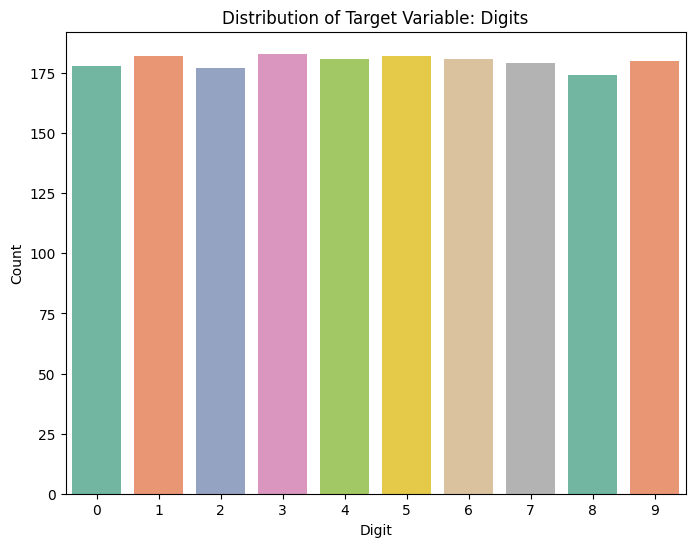

In [11]:
# Visualize the distribution of target variable (digits)
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution of Target Variable: Digits')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()

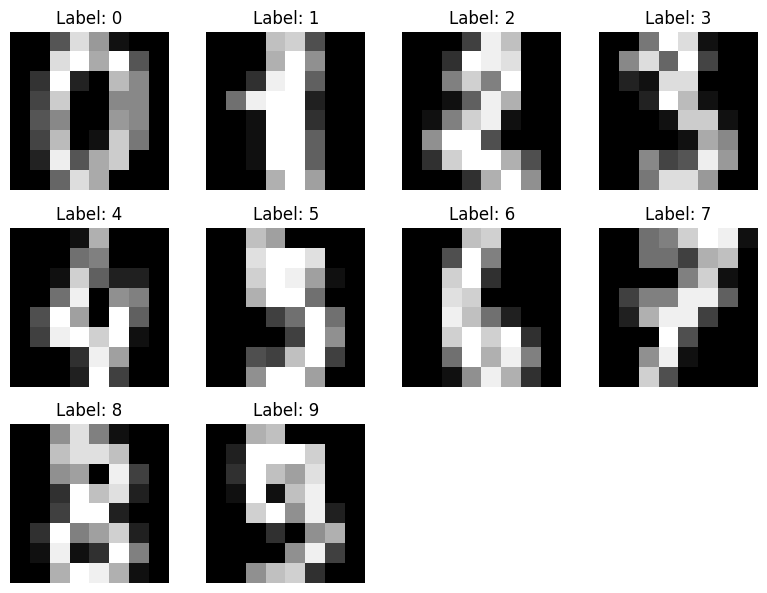

In [12]:
# Visualize the first few images from the dataset
plt.figure(figsize=(8, 8))
for i in range(10):  # Display the first 10 images
    plt.subplot(4, 4, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {digits.target[i]}")
plt.tight_layout()
plt.show()

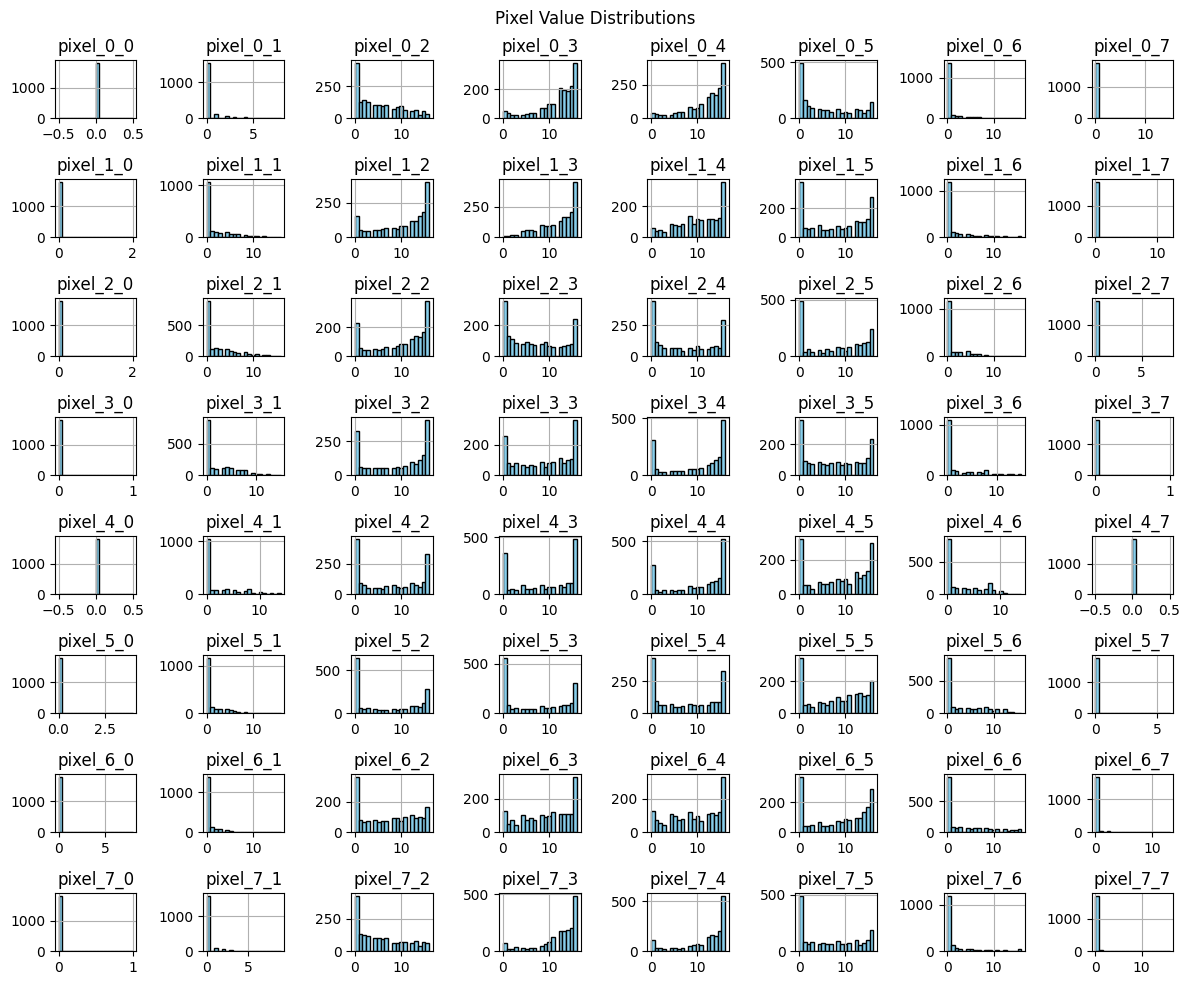

In [13]:
# Visualize the distribution of pixel values across all features (histograms)
df.drop('target', axis=1).hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Pixel Value Distributions')
plt.tight_layout()
plt.show()

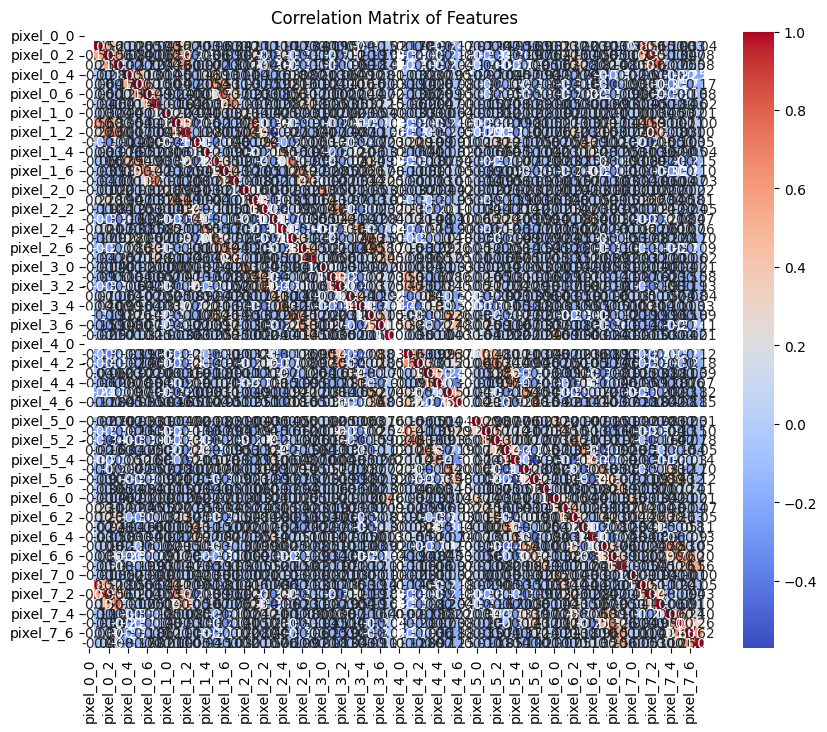

In [14]:
# Visualize the correlation matrix of the features
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('target', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [15]:
## 3. Splitting Data into Training and Test Sets

In [16]:
x = df.drop(columns=['target'])  
y = df['target'] 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training data shape (x_train, y_train): {x_train.shape}, {y_train.shape}")
print(f"Test data shape (x_test, y_test): {x_test.shape}, {y_test.shape}")

Training data shape (x_train, y_train): (1437, 64), (1437,)
Test data shape (x_test, y_test): (360, 64), (360,)


In [17]:
## 4. Data Preprocessing

In [18]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
## 5. Model Fitting, Test, Evaluation

In [24]:
model = SVC(kernel='linear', C=1)
model.fit(x_train, y_train)

accuracy = model.score(x_test, y_test)
print(f"Accuracy Model: {model} based on the test dataset: {accuracy:.5f}")

Accuracy Model: SVC(C=1, kernel='linear') based on the test dataset: 0.97500


In [25]:
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: Model {model}:")
print(cm)

print(f"\nClassification Report: Model {model}: ")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: Model {model}: {accuracy:.4f}")

cv_scores = cross_val_score(model, x_train, y_train, cv=5)
print(f"\nCross-validation scores: Model {model}:{cv_scores}")
print(f"\nAverage cross-validation score: Model {model}: {cv_scores.mean():.4f}")

Confusion Matrix: Model SVC(C=1, kernel='linear'):
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  1  0 45  1  0  0  0]
 [ 1  0  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  0  0  0  1  0  0 28  0]
 [ 0  0  0  1  0  0  0  1  0 38]]

Classification Report: Model SVC(C=1, kernel='linear'): 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.94      0.97      0.96        34
           4       1.00      1.00      1.00        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       1.00      0.93      0.97        30
           9       